# Actividad 2



## Configuración de los Requisitos

Este proyecto requiere:
- Python 3.7 o superior
- Scikit-Learn ≥ 1.0.1
- TensorFlow ≥ 2.8

In [1]:
import sys
from packaging import version
import sklearn
import tensorflow as tf
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

assert sys.version_info >= (3, 7)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
assert version.parse(tf.__version__) >= version.parse("2.8.0")

Vamos a definir los tamaños de fuente por defecto para que las figuras queden más bonitas:

In [4]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## Cargar el dataset

En esta sección cargaremos el dataset necesario para la Actividad 2.

In [6]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

El conjunto de entrenamiento MNIST contiene 60.000 imágenes en escala de grises, cada una de 28x28 píxeles:

In [7]:
X_train_full.shape

(60000, 28, 28)

La intensidad de cada píxel también se representa como un byte (de 0 a 255):

In [8]:
X_train_full.dtype

dtype('uint8')

Vamos a dividir el conjunto de entrenamiento completo en un conjunto de validación y un conjunto de entrenamiento (más pequeño).

También reducimos las intensidades de los píxeles al rango 0-1 y las convertimos en flotantes, dividiéndolas por 255:

In [9]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

Vamos a graficar una imagen utilizando la función `imshow()` de Matplotlib, con un mapa de colores `'binary'`:

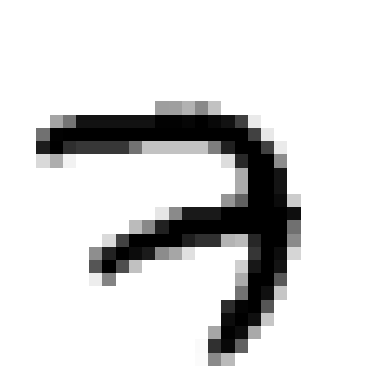

In [10]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

Las etiquetas son los IDs de las clases (representados como uint8), que van del 0 al 9. De manera conveniente, los IDs de las clases corresponden a los dígitos representados en las imágenes, por lo que no necesitamos un array de `class_names`:

In [11]:
y_train

array([7, 3, 4, ..., 5, 6, 8], dtype=uint8)

El conjunto de validación contiene 5.000 imágenes y el conjunto de prueba, 10.000:

In [12]:
X_valid.shape

(5000, 28, 28)

In [13]:
X_test.shape

(10000, 28, 28)

Veamos una muestra de las imágenes del conjunto de datos:

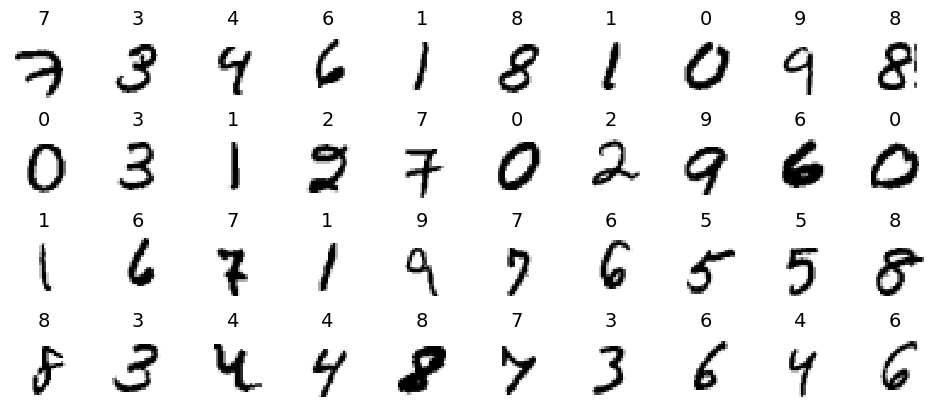

In [14]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(y_train[index])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

## Ejercicio 10

Entrena un MLP profundo en el conjunto de datos MNIST.
- Construye una red densa simple.
- Intenta alcanzar más del 98% de precisión ajustando manualmente los hiperparámetros.
- Busca la tasa de aprendizaje óptima
  - Incrementando la tasa de aprendizaje de manera exponencial
  - Graficando la pérdida
  - Encontrando el punto en el que la pérdida aumenta drásticamente.
- Ajusta los hiperparámetros utilizando Keras Tuner con todas las características avanzadas:
  - Guarda checkpoints
  - Utiliza early stopping
  - Grafica las curvas de aprendizaje con TensorBoard.



### Definir callback para la tasa de aprendizaje

Necesitaremos una llamada de retorno (callback) para aumentar la tasa de aprendizaje en cada iteración. También registrará la tasa de aprendizaje y la pérdida en cada iteración:

In [15]:
# Asignar el backend de Keras a la variable K
K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor # Factor para aumentar la tasa de aprendizaje
        self.rates = []      # Lista para almacenar las tasas de aprendizaje en cada batch
        self.losses = []     # Lista para almacenar las pérdidas en cada batch

    def on_batch_end(self, batch, logs=None):
        # Incrementar la tasa de aprendizaje multiplicándola por el factor
        lr = self.model.optimizer.learning_rate.numpy() * self.factor
        # Asignar la nueva tasa de aprendizaje al optimizador
        self.model.optimizer.learning_rate = lr
        self.rates.append(lr)            # Guardar la tasa de aprendizaje en la lista
        self.losses.append(logs["loss"]) # Guardar la pérdida en la lista

### Definir el Modelo

Con todas las capas necesarias.

In [16]:
# Limpiar cualquier sesión anterior de Keras
tf.keras.backend.clear_session()
# Establecer semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

In [17]:
# Definición del modelo secuencial de Keras
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),  # Aplanar las imágenes 28x28 en vectores de 784 elementos
    tf.keras.layers.Dense(300, activation="relu"),  # Capa densa con 300 neuronas y activación ReLU
    tf.keras.layers.Dense(100, activation="relu"),  # Capa densa con 100 neuronas y activación ReLU
    tf.keras.layers.Dense(10, activation="softmax") # Capa de salida con 10 neuronas y activación softmax para clasificación multiclase
])

C:\Users\maial\.conda\envs\unedenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compilar el Modelo

En Keras, debes llamar a `compile()` antes de `fit()` porque el proceso de **compilación** establece cómo el modelo va a ser entrenado, qué funciones de pérdida y optimizadores utilizar, y qué métricas vas a monitorizar. Es decir, `compile()` prepara el modelo para el entrenamiento.

Empezaremos con una pequeña tasa de aprendizaje de 1e-3, y la aumentaremos un 0,5% en cada iteración:

In [18]:
# Definir el optimizador SGD con una tasa de aprendizaje inicial de 1e-3
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)

# Compilar el modelo con la función de pérdida sparse_categorical_crossentropy y el optimizador definido
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

# Crear una instancia del callback ExponentialLearningRate con un factor de crecimiento de 1.005
expon_lr = ExponentialLearningRate(factor=1.005)

### Entrenar el Modelo para ajustar la Tasa de Aprendizaje

Ahora vamos a entrenar el modelo para una sola época, utilizando el callback de `ExponentialLearningRate` para ajustar la tasa de aprendizaje y registrar los cambios.


In [19]:
# Entrenar el modelo con los datos de entrenamiento y validación, utilizando el callback exponencial
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[expon_lr])

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4955 - loss: nan - val_accuracy: 0.0958 - val_loss: nan


Ahora podemos representar la pérdida en función de la tasa de aprendizaje:

Text(0, 0.5, 'Loss')

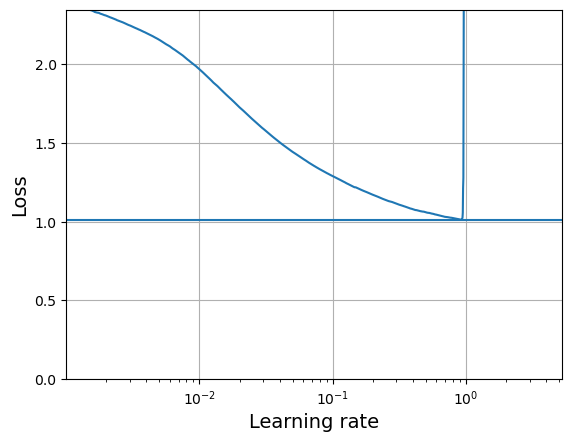

In [20]:
# Graficar la tasa de aprendizaje frente a la pérdida
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')  # Escala logarítmica en el eje x
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

### Compilar y Entrenar el Modelo definitivo

La pérdida empieza a dispararse violentamente cuando la tasa de aprendizaje supera los 6e-1, así que probemos a utilizar la mitad, a 3e-1:

In [21]:
# Limpiar cualquier sesión anterior de Keras y establecer semillas para reproducibilidad
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [22]:
# Definir nuevamente el modelo secuencial de Keras
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),  # Aplanar las imágenes 28x28 en vectores de 784 elementos
    tf.keras.layers.Dense(300, activation="relu"),  # Capa densa con 300 neuronas y activación ReLU
    tf.keras.layers.Dense(100, activation="relu"),  # Capa densa con 100 neuronas y activación ReLU
    tf.keras.layers.Dense(10, activation="softmax") # Capa de salida con 10 neuronas y activación softmax para clasificación multiclase
])

In [23]:
# Definir un optimizador SGD con una tasa de aprendizaje de 3e-1
optimizer = tf.keras.optimizers.SGD(learning_rate=3e-1)

# Compilar el modelo con la función de pérdida sparse_categorical_crossentropy y el optimizador definido
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [24]:
# Establecer el índice de ejecución del modelo y definir el directorio de logs
run_index = 1 # Incrementar este valor con cada ejecución
run_logdir = Path() / "my_mnist_logs" / "run_{:03d}".format(run_index)  # Ruta para almacenar los logs de ejecución
run_logdir

WindowsPath('my_mnist_logs/run_001')

Se crean tres callbacks adicionales:
- `EarlyStopping` para detener el entrenamiento si la pérdida no mejora.
- `ModelCheckpoint` para guardar el mejor modelo.
- `TensorBoard` para registrar información de entrenamiento en un directorio de logs.

Se entrena el modelo durante 100 épocas, utilizando los callbacks definidos.

In [25]:
# Crear un callback de EarlyStopping que detendrá el entrenamiento si la pérdida no mejora durante 20 épocas
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)

# Crear un callback de ModelCheckpoint que guardará el modelo con la mejor puntuación de validación
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_mnist_model.keras", save_best_only=True)

# Crear un callback de TensorBoard para registrar información de entrenamiento en un directorio de logs
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

# Entrenar el modelo durante 100 épocas, utilizando los callbacks definidos para guardar el mejor modelo, detener temprano y registrar en TensorBoard
history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8693 - loss: 0.4059 - val_accuracy: 0.9656 - val_loss: 0.1075
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 909us/step - accuracy: 0.9707 - loss: 0.1006 - val_accuracy: 0.9730 - val_loss: 0.0870
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 919us/step - accuracy: 0.9812 - loss: 0.0627 - val_accuracy: 0.9734 - val_loss: 0.0855
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 951us/step - accuracy: 0.9867 - loss: 0.0434 - val_accuracy: 0.9730 - val_loss: 0.0894
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 920us/step - accuracy: 0.9894 - loss: 0.0348 - val_accuracy: 0.9754 - val_loss: 0.0948
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 939us/step - accuracy: 0.9915 - loss: 0.0255 - val_accuracy: 0.9786 - val_loss: 0.0930
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 924us/step - accuracy: 0.9926 - loss: 0.0217 - val_accuracy: 0.9792 - val_loss: 0.0940
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 909us/step - accuracy: 0.

### Recuperación y evaluación del mejor modelo

Se carga el mejor modelo guardado durante el entrenamiento y se evalúa con los datos de prueba.

In [26]:
# Cargar el mejor modelo guardado durante el entrenamiento (el que obtuvo la mejor puntuación de validación)
model = tf.keras.models.load_model("my_mnist_model.keras") # rollback al mejor modelo

# Evaluar el modelo cargado con los datos de prueba
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step - accuracy: 0.9709 - loss: 0.0924


[0.0745900347828865, 0.9760000109672546]

Obtuvimos más de un 98% de precisión.

### TensorBoard

Por último, veamos las curvas de aprendizaje utilizando TensorBoard:

In [27]:
%tensorboard --logdir=./my_mnist_logs

UsageError: Line magic function `%tensorboard` not found.


## Experimento 1: Red con 3 capas ocultas y learning_rate=3e-1

El objetivo de este experimento es crear dos versiones con diferentes números de neuronas en las capas ocultas.

Para crear las dos versiones solicitadas, primero realiaremos varias pruebas con diferentes números de neuronas, para ver cómo se comporta la red neuronal con estos datos:

### Bucle de experimentación con diferentes números de neuronas

In [44]:
# Limpiar cualquier sesión anterior de Keras y establecer semillas para reproducibilidad
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [45]:
# Rango de neuronas para explorar
neuron_range = [200, 300, 400]

# Inicializar una lista para guardar los resultados
results = []

# Establecer el índice de ejecución
run_index = 1

for n1 in neuron_range:  # Primer capa
    for n2 in neuron_range:  # Segunda capa
        for n3 in neuron_range:  # Tercera capa
            if n1 >= n2 >= n3:  # Solo probar si cada capa más superficial tiene un número de neuronas mayor o igual al de las capas más profundas 
                print(f"Probando configuración # {run_index}: {n1}-{n2}-{n3}")
                
                # Definir el modelo con la configuración actual
                model = tf.keras.Sequential([
                    tf.keras.layers.Flatten(input_shape=[28, 28]),
                    tf.keras.layers.Dense(n1, activation="relu"),
                    tf.keras.layers.Dense(n2, activation="relu"),
                    tf.keras.layers.Dense(n3, activation="relu"),
                    tf.keras.layers.Dense(10, activation="softmax")
                ])
                
                # Compilar el modelo
                model.compile(loss="sparse_categorical_crossentropy",
                              optimizer=tf.keras.optimizers.SGD(learning_rate=3e-1),
                              metrics=["accuracy"])
    
                # Definir el directorio de logs
                run_logdir = Path() / "mnist_logs/exp1" / "run_{:03d}".format(run_index)
    
                # Crear un callback de EarlyStopping que detendrá el entrenamiento si la pérdida no mejora durante 10 épocas
                early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10)
                
                # Crear un callback de ModelCheckpoint que guardará el modelo con la mejor puntuación de validación
                checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("model/exp1/mnist_model_{:03d}.keras".format(run_index), save_best_only=True)
                
                # Crear un callback de TensorBoard para registrar información de entrenamiento en un directorio de logs
                tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
                
                # Entrenar el modelo durante 100 épocas, utilizando todo lo anterior
                history = model.fit(X_train, y_train, epochs=100,
                                    validation_data=(X_valid, y_valid),
                                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb],
                                    verbose=0)  # Silenciar salida
                           
                # Obtener la mejor métrica de validación
                best_val_loss = min(history.history["val_loss"])
                best_val_accuracy = history.history["val_accuracy"][history.history["val_loss"].index(best_val_loss)]
                
                # Guardar los resultados
                results.append((n1, n2, n3, best_val_accuracy, best_val_loss))
                print(f"Resultados para {n1}-{n2}-{n3}: val_accuracy={best_val_accuracy} val_loss={best_val_loss}")
                
                run_index = run_index+1

# Encontrar la mejor configuración
best_config = min(results, key=lambda x: x[4])
print(f"Mejor configuración: {best_config}")

Probando configuración # 1: 200-200-200
Resultados para 200-200-200: val_accuracy=0.979200005531311 val_loss=0.08506472408771515
Probando configuración # 2: 300-200-200
Resultados para 300-200-200: val_accuracy=0.9771999716758728 val_loss=0.0826788991689682
Probando configuración # 3: 300-300-200
Resultados para 300-300-200: val_accuracy=0.9782000184059143 val_loss=0.07832112163305283
Probando configuración # 4: 300-300-300
Resultados para 300-300-300: val_accuracy=0.974399983882904 val_loss=0.08261220157146454
Probando configuración # 5: 400-200-200
Resultados para 400-200-200: val_accuracy=0.9764000177383423 val_loss=0.07941961288452148
Probando configuración # 6: 400-300-200
Resultados para 400-300-200: val_accuracy=0.975600004196167 val_loss=0.08254358172416687
Probando configuración # 7: 400-300-300
Resultados para 400-300-300: val_accuracy=0.9801999926567078 val_loss=0.08284264802932739
Probando configuración # 8: 400-400-200
Resultados para 400-400-200: val_accuracy=0.9811999797

Vemos que la primera capa contiene más neuronas que las capas posteriores. Esta arquitectura puede representar que la primera capa es la encargada de aprender características más generales de los datos, y las capas posteriores se encargan de refinar. Siendo este el caso, puede tener sentido que las capas posteriores contengan menos neuronas. MIRAR ARQUITECTURA JERÁRQUICA EN LOS APUNTES.

In [54]:
# Cargar el mejor modelo guardado durante el entrenamiento (el que obtuvo la mejor puntuación de validación)
model = tf.keras.models.load_model("./model/exp1/mnist_model_010.keras") # rollback al mejor modelo

# Evaluar el modelo cargado con los datos de prueba
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9746 - loss: 0.0818


[0.0656992644071579, 0.9793999791145325]

### Comparación v1 vs v2

## Experimento 2: Red con 4 capas ocultas y learning_rate=3e-1

### Bucle de experimentación con diferentes números de neuronas

In [46]:
# Limpiar cualquier sesión anterior de Keras y establecer semillas para reproducibilidad
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [47]:
# Rango de neuronas para explorar
neuron_range = [200, 300, 400]

# Inicializar una lista para guardar los resultados
results = []

# Establecer el índice de ejecución
run_index = 1

for n1 in neuron_range:  # Primer capa
    for n2 in neuron_range:  # Segunda capa
        for n3 in neuron_range:  # Tercera capa
            for n4 in neuron_range:  # Cuarta capa
                if n1 >= n2 >= n3 >= n4:  # Solo probar si cada capa más superficial tiene un número de neuronas mayor o igual al de las capas más profundas
                    print(f"Probando configuración # {run_index}: {n1}-{n2}-{n3}-{n4}")
                    
                    # Definir el modelo con la configuración actual
                    model = tf.keras.Sequential([
                        tf.keras.layers.Flatten(input_shape=[28, 28]),
                        tf.keras.layers.Dense(n1, activation="relu"),
                        tf.keras.layers.Dense(n2, activation="relu"),
                        tf.keras.layers.Dense(n3, activation="relu"),
                        tf.keras.layers.Dense(n4, activation="relu"),  # Cuarta capa añadida
                        tf.keras.layers.Dense(10, activation="softmax")
                    ])
                    
                    # Compilar el modelo
                    model.compile(loss="sparse_categorical_crossentropy",
                                  optimizer=tf.keras.optimizers.SGD(learning_rate=3e-1),
                                  metrics=["accuracy"])
    
                    # Definir el directorio de logs
                    run_logdir = Path() / "mnist_logs/exp2" / "run_{:03d}".format(run_index)
    
                    # Crear un callback de EarlyStopping que detendrá el entrenamiento si la pérdida no mejora durante 10 épocas
                    early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10)
                    
                    # Crear un callback de ModelCheckpoint que guardará el modelo con la mejor puntuación de validación
                    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("model/exp2/mnist_model_{:03d}.keras".format(run_index), save_best_only=True)
                    
                    # Crear un callback de TensorBoard para registrar información de entrenamiento en un directorio de logs
                    tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
                    
                    # Entrenar el modelo durante 100 épocas, utilizando todo lo anterior
                    history = model.fit(X_train, y_train, epochs=100,
                                        validation_data=(X_valid, y_valid),
                                        callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb],
                                        verbose=0)  # Silenciar salida
                           
                    # Obtener la mejor métrica de validación
                    best_val_loss = min(history.history["val_loss"])
                    best_val_accuracy = history.history["val_accuracy"][history.history["val_loss"].index(best_val_loss)]
                    
                    # Guardar los resultados
                    results.append((n1, n2, n3, n4, best_val_accuracy, best_val_loss))
                    print(f"Resultados para {n1}-{n2}-{n3}-{n4}: val_accuracy={best_val_accuracy} val_loss={best_val_loss}")
                    
                    run_index = run_index + 1

# Encontrar la mejor configuración
best_config = min(results, key=lambda x: x[5])
print(f"Mejor configuración: {best_config}")

Probando configuración # 1: 200-200-200-200
Resultados para 200-200-200-200: val_accuracy=0.9750000238418579 val_loss=0.08688898384571075
Probando configuración # 2: 300-200-200-200
Resultados para 300-200-200-200: val_accuracy=0.978600025177002 val_loss=0.08075166493654251
Probando configuración # 3: 300-300-200-200
Resultados para 300-300-200-200: val_accuracy=0.9796000123023987 val_loss=0.08747853338718414
Probando configuración # 4: 300-300-300-200
Resultados para 300-300-300-200: val_accuracy=0.9828000068664551 val_loss=0.0788828432559967
Probando configuración # 5: 300-300-300-300
Resultados para 300-300-300-300: val_accuracy=0.9757999777793884 val_loss=0.07851768285036087
Probando configuración # 6: 400-200-200-200
Resultados para 400-200-200-200: val_accuracy=0.9769999980926514 val_loss=0.08415214717388153
Probando configuración # 7: 400-300-200-200
Resultados para 400-300-200-200: val_accuracy=0.979200005531311 val_loss=0.08009421080350876
Probando configuración # 8: 400-300-3

In [56]:
# Cargar el mejor modelo guardado durante el entrenamiento (el que obtuvo la mejor puntuación de validación)
model = tf.keras.models.load_model("./model/exp2/mnist_model_008.keras") # rollback al mejor modelo

# Evaluar el modelo cargado con los datos de prueba
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9717 - loss: 0.1097


[0.0880286768078804, 0.9761999845504761]

### Comparación v1 vs v2

## Experimento 3: Cambiar learning_rate para la mejor red de 3 capas

Y comparar con el resultado obtenido en el Experimento 1.

In [48]:
# Limpiar cualquier sesión anterior de Keras
tf.keras.backend.clear_session()
# Establecer semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

In [49]:
# Definir el modelo con la mejor configuración
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(400, activation="relu"),
    tf.keras.layers.Dense(400, activation="relu"),
    tf.keras.layers.Dense(400, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Definir el optimizador SGD con una tasa de aprendizaje inicial de 1e-3
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)

# Compilar el modelo con la función de pérdida sparse_categorical_crossentropy y el optimizador definido
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

# Crear una instancia del callback ExponentialLearningRate con un factor de crecimiento de 1.005
expon_lr = ExponentialLearningRate(factor=1.005)

# Entrenar el modelo con los datos de entrenamiento y validación, utilizando el callback exponencial
# Solo una época
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[expon_lr])

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4950 - loss: nan - val_accuracy: 0.0958 - val_loss: nan


Text(0, 0.5, 'Loss')

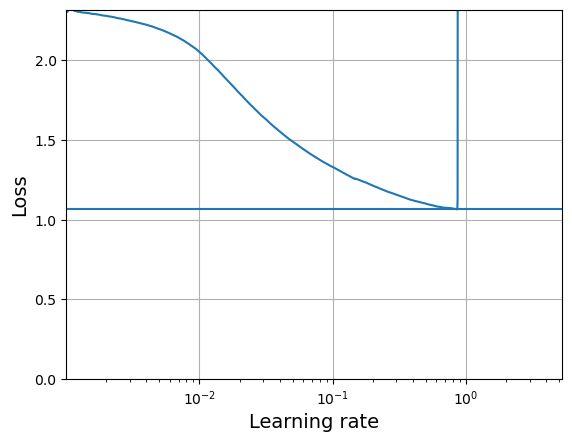

In [50]:
# Graficar la tasa de aprendizaje frente a la pérdida
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')  # Escala logarítmica en el eje x
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

Me sale un Learning Rate muy parecido, igual podría decir que empieza a descender cuando la tasa de aprendizaje supera los 7e-1, así que probemos a utilizar la mitad, a 4.5e-1?

PENDIENTE DESARROLLAR SI QUIERO PROBAR OTRO LEARNING RATE

## Experimento 4: Cambiar learning_rate para la mejor red de 4 capas

Y comparar con el resultado obtenido en el Experimento 2.

In [51]:
# Limpiar cualquier sesión anterior de Keras
tf.keras.backend.clear_session()
# Establecer semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

In [52]:
# Definir el modelo con la mejor configuración
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(400, activation="relu"),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Definir el optimizador SGD con una tasa de aprendizaje inicial de 1e-3
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)

# Compilar el modelo con la función de pérdida sparse_categorical_crossentropy y el optimizador definido
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

# Crear una instancia del callback ExponentialLearningRate con un factor de crecimiento de 1.005
expon_lr = ExponentialLearningRate(factor=1.005)

# Entrenar el modelo con los datos de entrenamiento y validación, utilizando el callback exponencial
# Solo una época
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[expon_lr])

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4626 - loss: nan - val_accuracy: 0.0958 - val_loss: nan


Text(0, 0.5, 'Loss')

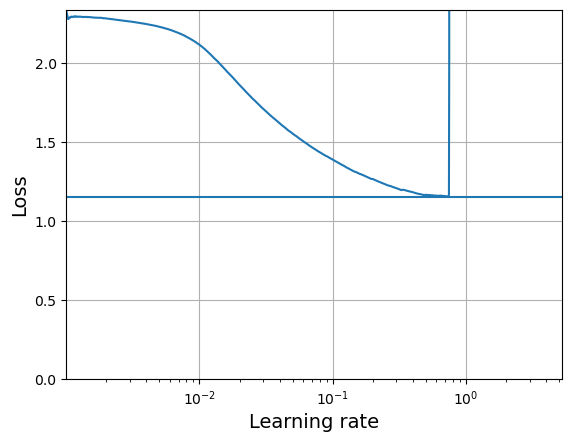

In [53]:
# Graficar la tasa de aprendizaje frente a la pérdida
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')  # Escala logarítmica en el eje x
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

IGUAL,

Me sale un Learning Rate muy parecido, igual podría decir que empieza a descender cuando la tasa de aprendizaje supera los 7e-1, así que probemos a utilizar la mitad, a 4.5e-1?

PENDIENTE DESARROLLAR SI QUIERO PROBAR OTRO LEARNING RATE